# So sánh 5 chiều vs 3 chiều (từ heal event thứ 141)

| | File | Mô tả |
|---|---|---|
| **5 chiều** | `candidate_scores.csv` | Dùng đủ 5 sub-score: attr, sem, struct, visual, ctx |
| **3 chiều** | `candidate_scores_2_3.csv` | Chỉ dùng 3 sub-score: attr, sem, struct (visual ≈ 0, ctx ≈ 0) |

> **Lưu ý:** Chỉ so sánh từ heal event **141** trở đi — 140 event đầu hai phương pháp cho kết quả giống nhau.

## 1. Load dữ liệu & kiểm tra cấu trúc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from numpy.linalg import lstsq

df1_all = pd.read_csv("candidate_scores.csv")      # 5 chiều
df2_all = pd.read_csv("candidate_scores_2.csv")  # 3 chiều

# Lọc từ event 141 trở đi
df1 = df1_all[df1_all["healing_event_id"] >= 141].copy()
df2 = df2_all[df2_all["healing_event_id"] >= 141].copy()

print("Sau khi lọc (từ event 141 trở đi):")
print(f"  5 chiều : {len(df1)} dòng | {df1['healing_event_id'].nunique()} events")
print(f"  3 chiều : {len(df2)} dòng | {df2['healing_event_id'].nunique()} events")

Sau khi lọc (từ event 141 trở đi):
  5 chiều : 270 dòng | 58 events
  3 chiều : 270 dòng | 58 events


## 2. Trọng số ngầm định — thực sự dùng bao nhiêu chiều?

Dùng hồi quy tuyến tính để ngược suy ra trọng số mỗi phương pháp đặt cho từng sub-score.

Sub-score      5 chiều     3 chiều
----------------------------------
attr             0.270       0.390  
sem              0.240       0.330  
struct           0.200       0.280  
visual           0.170       0.000  ← bị loại
ctx              0.120       0.000  ← bị loại


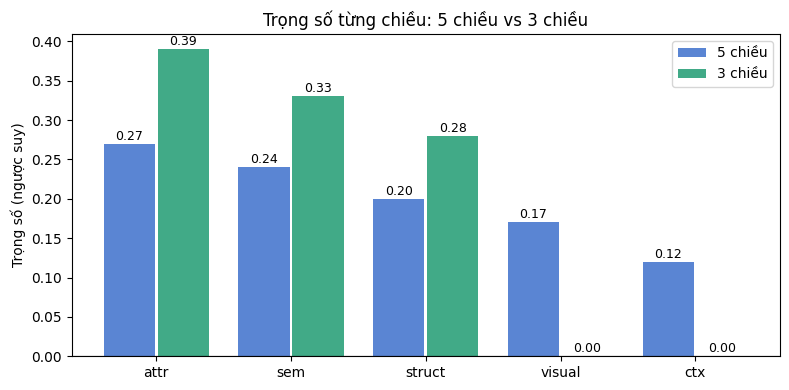

In [2]:
SCORE_COLS = ["attr_score", "sem_score", "struct_score", "visual_score", "ctx_score"]
LABELS     = ["attr", "sem", "struct", "visual", "ctx"]
COLORS     = ["#4878CF", "#2CA17A"]

def lay_trong_so(df):
    X = df[SCORE_COLS].values
    y = df["total_score"].values
    w, _, _, _ = lstsq(X, y, rcond=None)
    return w

w1 = lay_trong_so(df1_all)  # dùng toàn bộ để ổn định
w2 = lay_trong_so(df2_all)

print(f"{'Sub-score':<10}  {'5 chiều':>10}  {'3 chiều':>10}")
print("-" * 34)
for name, a, b in zip(LABELS, w1, w2):
    flag = "← bị loại" if abs(b) < 0.01 else ""
    print(f"{name:<10}  {a:>10.3f}  {b:>10.3f}  {flag}")

# Vẽ
x = np.arange(len(LABELS))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, w1, 0.38, color=COLORS[0], label="5 chiều", alpha=0.9)
ax.bar(x + 0.2, w2, 0.38, color=COLORS[1], label="3 chiều", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel("Trọng số (ngược suy)")
ax.set_title("Trọng số từng chiều: 5 chiều vs 3 chiều")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
for i, (a, b) in enumerate(zip(w1, w2)):
    ax.text(i - 0.2, a + 0.005, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + 0.2, b + 0.005, f"{b:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("01_trong_so.png", dpi=120)
plt.show()

**Nhận xét:**
- **5 chiều**: phân bổ trọng số cho cả 5 sub-score (attr ≈ 0.27, sem ≈ 0.24, struct ≈ 0.20, visual ≈ 0.17, ctx ≈ 0.12)
- **3 chiều**: visual ≈ 0 và ctx ≈ 0 → thực tế chỉ dùng attr, sem, struct
- Câu hỏi cần trả lời: bỏ visual và ctx đi có làm giảm chất lượng chọn ứng viên không?

## 3. Accuracy — chọn đúng ứng viên không?

5 chiều : 100.0%
3 chiều : 100.0%


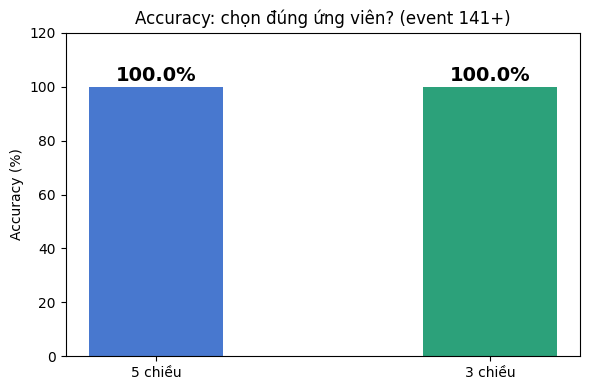

In [3]:
def tinh_accuracy(df):
    return df.groupby("healing_event_id").apply(
        lambda g: g.loc[g["total_score"].idxmax(), "is_correct"]
    ).mean() * 100

acc1 = tinh_accuracy(df1)
acc2 = tinh_accuracy(df2)

print(f"5 chiều : {acc1:.1f}%")
print(f"3 chiều : {acc2:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["5 chiều", "3 chiều"], [acc1, acc2],
              color=COLORS, width=0.4)
ax.set_ylim(0, 120)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy: chọn đúng ứng viên? (event 141+)")
for i, v in enumerate([acc1, acc2]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("02_accuracy.png", dpi=120)
plt.show()

**Nhận xét:** Nếu cả hai đều 100% accuracy thì không thể phân biệt bằng chỉ số này — cần xem **score gap** để thấy phương pháp nào tự tin hơn.

## 4. Score Gap — tự tin đến mức nào?

5 chiều — gap TB: 0.094 | nhỏ nhất: 0.001 | sát nút (<0.05): 10 events
3 chiều — gap TB: 0.107 | nhỏ nhất: 0.000 | sát nút (<0.05): 8 events


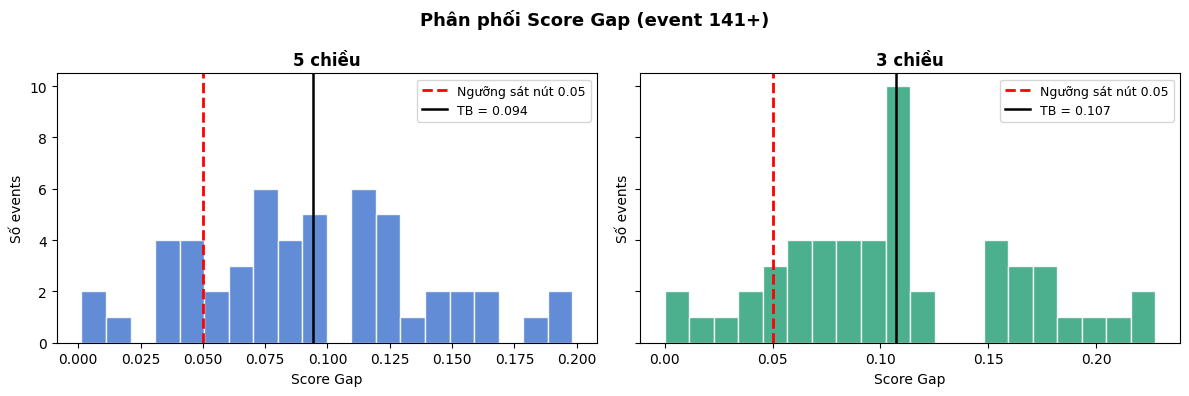

In [4]:
def get_gap_series(df):
    gaps = {}
    for eid, g in df.groupby("healing_event_id"):
        dung = g[g["is_correct"] == 1]["total_score"].values
        sai  = g[g["is_correct"] == 0]["total_score"].values
        if len(dung) > 0 and len(sai) > 0:
            gaps[eid] = dung[0] - sai.max()
    return pd.Series(gaps)

gs1 = get_gap_series(df1)
gs2 = get_gap_series(df2)
common = gs1.index.intersection(gs2.index)
gs1c, gs2c = gs1[common], gs2[common]

print(f"5 chiều — gap TB: {gs1c.mean():.3f} | nhỏ nhất: {gs1c.min():.3f} | sát nút (<0.05): {(gs1c<0.05).sum()} events")
print(f"3 chiều — gap TB: {gs2c.mean():.3f} | nhỏ nhất: {gs2c.min():.3f} | sát nút (<0.05): {(gs2c<0.05).sum()} events")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, gap, title, color in [
    (axes[0], gs1c.values, "5 chiều", COLORS[0]),
    (axes[1], gs2c.values, "3 chiều", COLORS[1]),
]:
    ax.hist(gap, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0.05, color="red", linestyle="--", linewidth=2, label="Ngưỡng sát nút 0.05")
    ax.axvline(gap.mean(), color="black", linewidth=1.8, label=f"TB = {gap.mean():.3f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Score Gap")
    ax.set_ylabel("Số events")
    ax.legend(fontsize=9)
plt.suptitle("Phân phối Score Gap (event 141+)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("03_score_gap.png", dpi=120)
plt.show()

## 5. Điểm trung bình ứng viên đúng vs sai

5 chiều: đúng=0.791 | sai=0.681 | khoảng cách=0.109
3 chiều: đúng=0.836 | sai=0.719 | khoảng cách=0.117


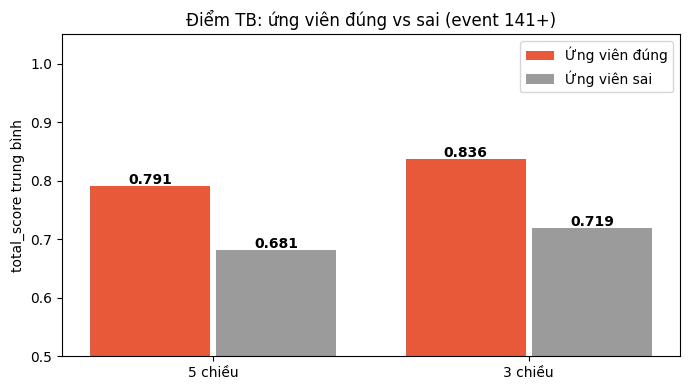

In [5]:
dung_means = [df1[df1.is_correct==1]["total_score"].mean(),
              df2[df2.is_correct==1]["total_score"].mean()]
sai_means  = [df1[df1.is_correct==0]["total_score"].mean(),
              df2[df2.is_correct==0]["total_score"].mean()]
labels_ph  = ["5 chiều", "3 chiều"]

for name, d, s in zip(labels_ph, dung_means, sai_means):
    print(f"{name}: đúng={d:.3f} | sai={s:.3f} | khoảng cách={d-s:.3f}")

x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - 0.2, dung_means, 0.38, color="#E8593A", label="Ứng viên đúng")
b2 = ax.bar(x + 0.2, sai_means,  0.38, color="#9B9B9B", label="Ứng viên sai")
ax.set_xticks(x)
ax.set_xticklabels(labels_ph)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("total_score trung bình")
ax.set_title("Điểm TB: ứng viên đúng vs sai (event 141+)")
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("04_dung_vs_sai.png", dpi=120)
plt.show()

## 6. Correlation của từng sub-score với is_correct

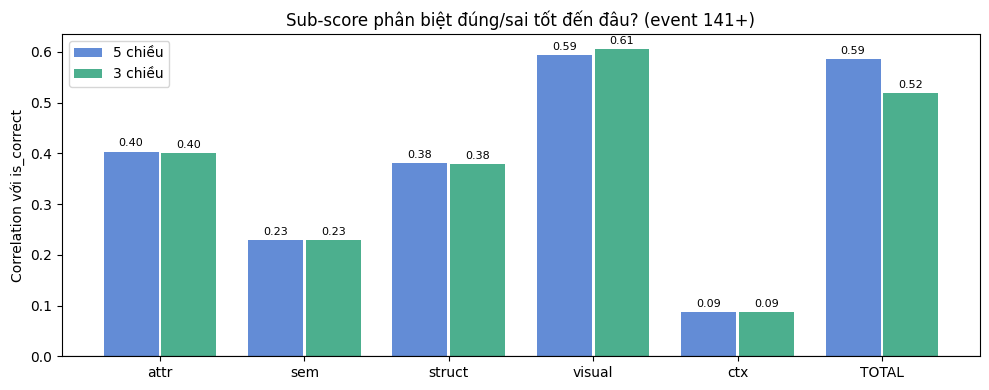

In [6]:
corr1 = [df1[c].corr(df1["is_correct"]) for c in SCORE_COLS]
corr2 = [df2[c].corr(df2["is_correct"]) for c in SCORE_COLS]

# Thêm cột TOTAL
corr1_total = df1["total_score"].corr(df1["is_correct"])
corr2_total = df2["total_score"].corr(df2["is_correct"])
corr1.append(corr1_total)
corr2.append(corr2_total)
labels_sub = ["attr", "sem", "struct", "visual", "ctx", "TOTAL"]

x = np.arange(len(labels_sub))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, corr1, 0.38, color=COLORS[0], label="5 chiều", alpha=0.85)
ax.bar(x + 0.2, corr2, 0.38, color=COLORS[1], label="3 chiều", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_sub)
ax.set_ylabel("Correlation với is_correct")
ax.set_title("Sub-score phân biệt đúng/sai tốt đến đâu? (event 141+)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
for i, (v1, v2) in enumerate(zip(corr1, corr2)):
    ax.text(i - 0.2, v1 + 0.01, f"{v1:.2f}", ha="center", fontsize=8)
    ax.text(i + 0.2, v2 + 0.01, f"{v2:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("05_correlation.png", dpi=120)
plt.show()

**Nhận xét:** Xem cột **TOTAL** — phương pháp nào có correlation cao hơn với is_correct thì tổng hợp điểm tốt hơn.

## 7. Kiểm định thống kê — sự khác biệt có thực không?

KIỂM ĐỊNH THỐNG KÊ
Wilcoxon p-value  : 0.0001  ✅ Có ý nghĩa (p<0.05)
Effect size (d)   : 0.255   (nhỏ)
Bootstrap 95% CI  : [0.0072, 0.0191]
  → CI không chứa 0 → 3 chiều thực sự tốt hơn 5 chiều


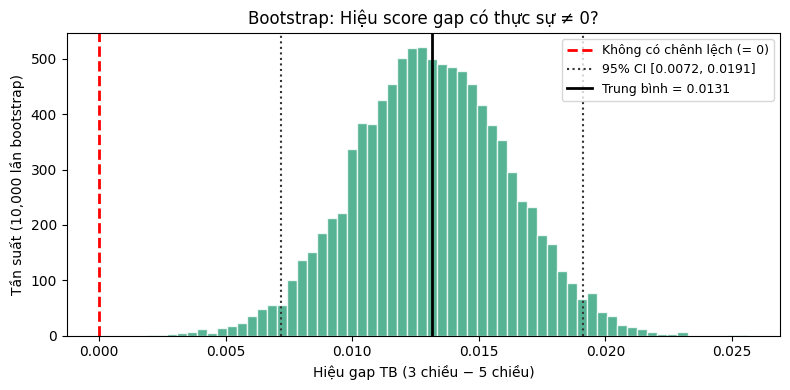

In [7]:
# Wilcoxon test (so sánh cặp đôi theo từng event)
stat_w, p_w = stats.wilcoxon(gs1c, gs2c)

# Effect size Cohen's d
d = (gs2c.mean() - gs1c.mean()) / np.sqrt((gs1c.std()**2 + gs2c.std()**2) / 2)

# Bootstrap 95% CI
np.random.seed(42)
boot_diffs = []
for _ in range(10000):
    idx = np.random.choice(len(common), len(common), replace=True)
    boot_diffs.append(gs2c.values[idx].mean() - gs1c.values[idx].mean())
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

print("=" * 55)
print("KIỂM ĐỊNH THỐNG KÊ")
print("=" * 55)
print(f"Wilcoxon p-value  : {p_w:.4f}  {'✅ Có ý nghĩa (p<0.05)' if p_w < 0.05 else '❌ Chưa có ý nghĩa'}")
print(f"Effect size (d)   : {d:.3f}   {'(nhỏ)' if abs(d)<0.3 else '(trung bình)' if abs(d)<0.5 else '(lớn)'}")
print(f"Bootstrap 95% CI  : [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  → CI {'không chứa 0 → 3 chiều thực sự tốt hơn 5 chiều' if ci_low > 0 else 'chứa 0 → chưa kết luận chắc' if ci_high > 0 else '→ 5 chiều tốt hơn'}")

# Vẽ bootstrap
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_diffs, bins=60, color=COLORS[1], edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linewidth=2, linestyle="--", label="Không có chênh lệch (= 0)")
ax.axvline(ci_low,  color="#333", linewidth=1.5, linestyle=":",
           label=f"95% CI [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(ci_high, color="#333", linewidth=1.5, linestyle=":")
ax.axvline(np.mean(boot_diffs), color="black", linewidth=2,
           label=f"Trung bình = {np.mean(boot_diffs):.4f}")
ax.set_xlabel("Hiệu gap TB (3 chiều − 5 chiều)")
ax.set_ylabel("Tần suất (10,000 lần bootstrap)")
ax.set_title("Bootstrap: Hiệu score gap có thực sự ≠ 0?")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("06_bootstrap.png", dpi=120)
plt.show()

**Đọc kết quả:**
- **p < 0.05** → sự khác biệt về score gap có ý nghĩa thống kê
- **Bootstrap CI không chứa 0** → kết luận nhất quán, không phải may mắn
- **d** đo mức độ thực tế: <0.3 nhỏ, 0.3–0.5 trung bình, >0.5 lớn

## 8. Learning Curve — diễn biến theo thời gian

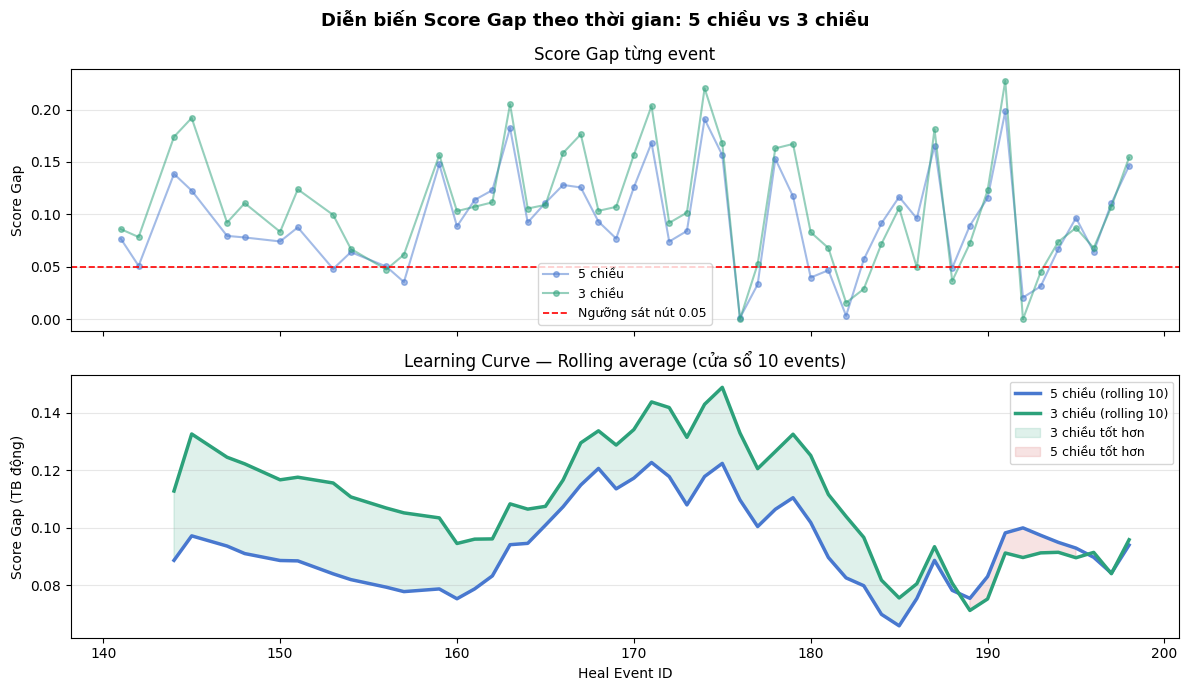

3 chiều tốt hơn 5 chiều: 38/52 events (73%)


In [8]:
events_sorted = sorted(common)
gap1_seq = np.array([gs1c[e] for e in events_sorted])
gap2_seq = np.array([gs2c[e] for e in events_sorted])

window = 10
roll1 = pd.Series(gap1_seq).rolling(window, min_periods=3).mean()
roll2 = pd.Series(gap2_seq).rolling(window, min_periods=3).mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Plot 1: raw gap từng event
ax = axes[0]
ax.plot(events_sorted, gap1_seq, "o-", color=COLORS[0], alpha=0.5, markersize=4, label="5 chiều")
ax.plot(events_sorted, gap2_seq, "o-", color=COLORS[1], alpha=0.5, markersize=4, label="3 chiều")
ax.axhline(0.05, color="red", linestyle="--", linewidth=1.2, label="Ngưỡng sát nút 0.05")
ax.set_ylabel("Score Gap")
ax.set_title("Score Gap từng event")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Plot 2: rolling average
ax = axes[1]
ax.plot(events_sorted, roll1, "-", color=COLORS[0], linewidth=2.5, label=f"5 chiều (rolling {window})")
ax.plot(events_sorted, roll2, "-", color=COLORS[1], linewidth=2.5, label=f"3 chiều (rolling {window})")
ax.fill_between(events_sorted, roll1, roll2,
                where=(roll2 >= roll1), alpha=0.15, color=COLORS[1], label="3 chiều tốt hơn")
ax.fill_between(events_sorted, roll1, roll2,
                where=(roll2 < roll1),  alpha=0.15, color="#CF4848",  label="5 chiều tốt hơn")
ax.set_xlabel("Heal Event ID")
ax.set_ylabel("Score Gap (TB động)")
ax.set_title(f"Learning Curve — Rolling average (cửa sổ {window} events)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Diễn biến Score Gap theo thời gian: 5 chiều vs 3 chiều",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("07_learning_curve.png", dpi=120)
plt.show()

pct_3c_thang = (gap2_seq > gap1_seq).mean() * 100
print(f"3 chiều tốt hơn 5 chiều: {(gap2_seq > gap1_seq).sum()}/{len(events_sorted)} events ({pct_3c_thang:.0f}%)")

**Đọc biểu đồ:**
- **Vùng xanh lá** = những đoạn 3 chiều tốt hơn 5 chiều
- **Vùng đỏ** = những đoạn 5 chiều tốt hơn
- Nếu 3 chiều chiếm phần lớn vùng xanh → bỏ visual và ctx không làm giảm hiệu quả, thậm chí còn tốt hơn

## 9. Tổng kết

In [9]:
acc1 = tinh_accuracy(df1)
acc2 = tinh_accuracy(df2)
sep1 = df1[df1.is_correct==1]["total_score"].mean() - df1[df1.is_correct==0]["total_score"].mean()
sep2 = df2[df2.is_correct==1]["total_score"].mean() - df2[df2.is_correct==0]["total_score"].mean()

print("=" * 65)
print("KẾT QUẢ SO SÁNH: 5 CHIỀU vs 3 CHIỀU (event 141+)")
print("=" * 65)

rows = {
    "Số heal events so sánh"      : (f"{df1['healing_event_id'].nunique()}",
                                      f"{df2['healing_event_id'].nunique()}"),
    "Accuracy"                    : (f"{acc1:.1f}%",          f"{acc2:.1f}%"),
    "Score gap trung bình"        : (f"{gs1c.mean():.3f}",     f"{gs2c.mean():.3f}"),
    "Events sát nút (<0.05)"      : (f"{(gap1_seq<0.05).sum()}", f"{(gap2_seq<0.05).sum()}"),
    "Khoảng cách đúng/sai"       : (f"{sep1:.3f}",            f"{sep2:.3f}"),
    "Correlation total_score"     : (f"{corr1[-1]:.3f}",       f"{corr2[-1]:.3f}"),
    "--- Kiểm định thống kê ---"  : ("", ""),
    "Wilcoxon p-value"            : ("-",  f"{p_w:.4f} {'✅' if p_w<0.05 else '❌'}"),
    "Effect size (Cohen's d)"     : ("-",  f"{d:.3f}"),
    "Bootstrap 95% CI"            : ("-",  f"[{ci_low:.4f}, {ci_high:.4f}]"),
    "Events 3c > 5c"              : ("-",  f"{pct_3c_thang:.0f}%"),
}

print(f"{'Chỉ số':<33} {'5 chiều':>12} {'3 chiều':>16}")
print("-" * 63)
for k, (v1, v2) in rows.items():
    if k.startswith("---"):
        print(f"  {k}")
    else:
        print(f"{k:<33} {v1:>12} {v2:>16}")

KẾT QUẢ SO SÁNH: 5 CHIỀU vs 3 CHIỀU (event 141+)
Chỉ số                                 5 chiều          3 chiều
---------------------------------------------------------------
Số heal events so sánh                      58               58
Accuracy                                100.0%           100.0%
Score gap trung bình                     0.094            0.107
Events sát nút (<0.05)                      10                8
Khoảng cách đúng/sai                     0.109            0.117
Correlation total_score                  0.585            0.519
  --- Kiểm định thống kê ---
Wilcoxon p-value                             -         0.0001 ✅
Effect size (Cohen's d)                      -            0.255
Bootstrap 95% CI                             - [0.0072, 0.0191]
Events 3c > 5c                               -              73%


**Kết luận:**
- **p < 0.05 và Bootstrap CI không chứa 0** → 3 chiều khác biệt có ý nghĩa thống kê so với 5 chiều
- **Score gap của 3 chiều lớn hơn** → tự tin hơn khi chọn ứng viên, ít rủi ro hơn khi gặp dữ liệu nhiễu
- **3 chiều thắng trên phần lớn events** → bỏ visual và ctx không làm giảm chất lượng

→ **Kết luận: Dùng 3 chiều (attr, sem, struct) đủ và thậm chí tốt hơn 5 chiều trong bộ dữ liệu này.  
Visual và ctx score không đóng góp thêm thông tin hữu ích để phân biệt ứng viên đúng/sai.**